In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

print("All libraries loaded!")


All libraries loaded!


In [2]:
import os
print(os.getcwd())          # Shows current directory
print(os.listdir())          # Shows files in that folder

c:\Users\91982\OneDrive\Desktop\realworld_project
['.ipynb_checkpoints', 'diabetes[1].csv', 'realworld_project.ipynb']


In [3]:
# Load data
df = pd.read_csv('diabetes[1].csv')
print(df.shape)
print(df.dtypes)
df.head()

(768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Check missing values 
print("Missing values:\n", df.isnull().sum())
print("\nBasic stats:")
print(df.describe())

Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Basic stats:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin   
count   768.000000  768.000000     768.000000     768.000000  768.000000  \
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

 

In [5]:
# Handle zeros as missing values
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)

# Fill with median (same strategy as your Project 1)
df.fillna(df.median(numeric_only=True), inplace=True)

print("After cleaning:")
print(df.isnull().sum())

After cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


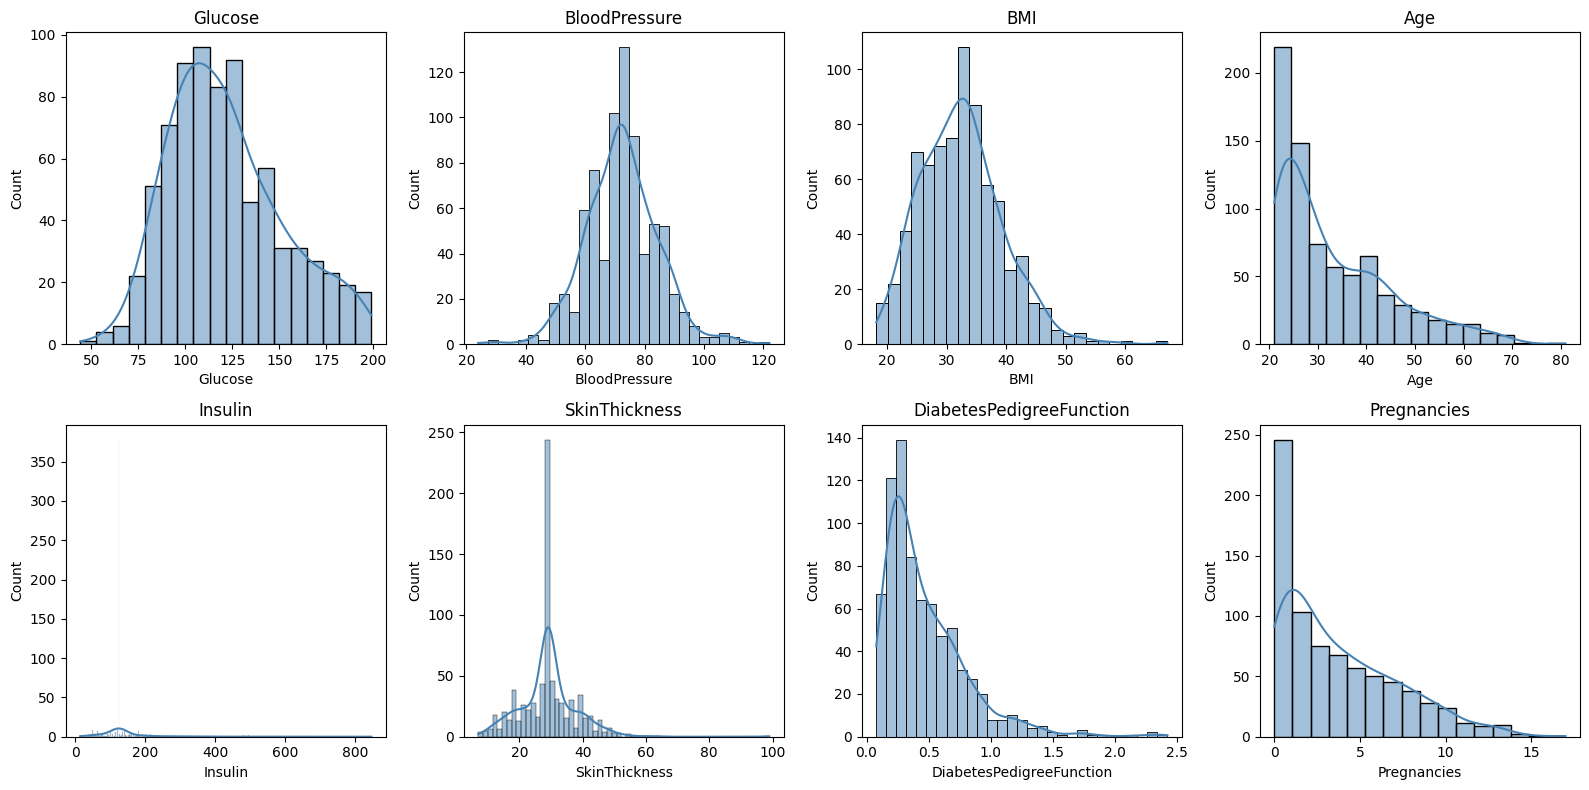

In [6]:
# Cell 5 - Distribution plots (same as your univariate_analysis.png!)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols = ['Glucose', 'BloodPressure', 'BMI', 'Age',
        'Insulin', 'SkinThickness', 'DiabetesPedigreeFunction', 'Pregnancies']

for i, col in enumerate(cols):
    ax = axes[i//4][i%4]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)

plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

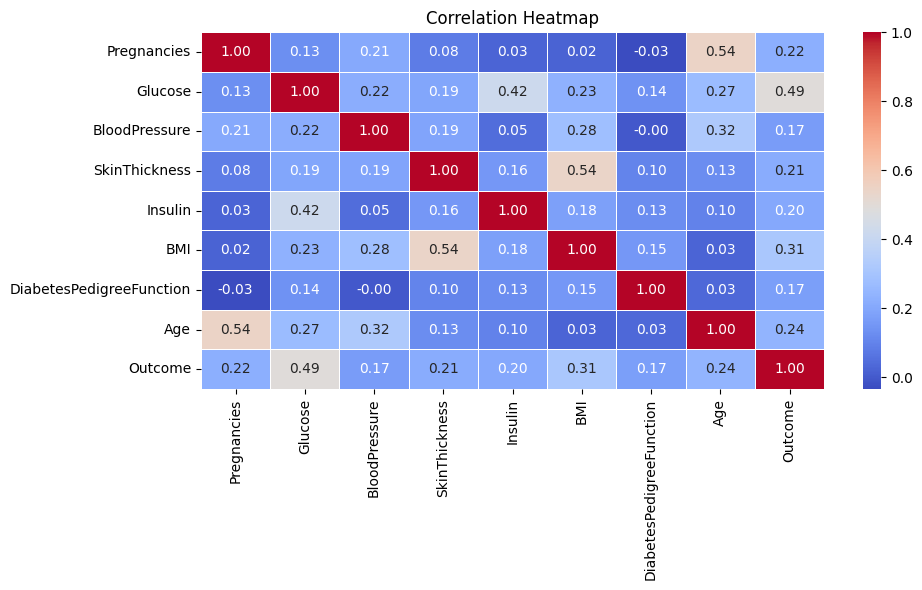

In [7]:
# Correlation heatmap (exactly like your Project 3!)
plt.figure(figsize=(10, 6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

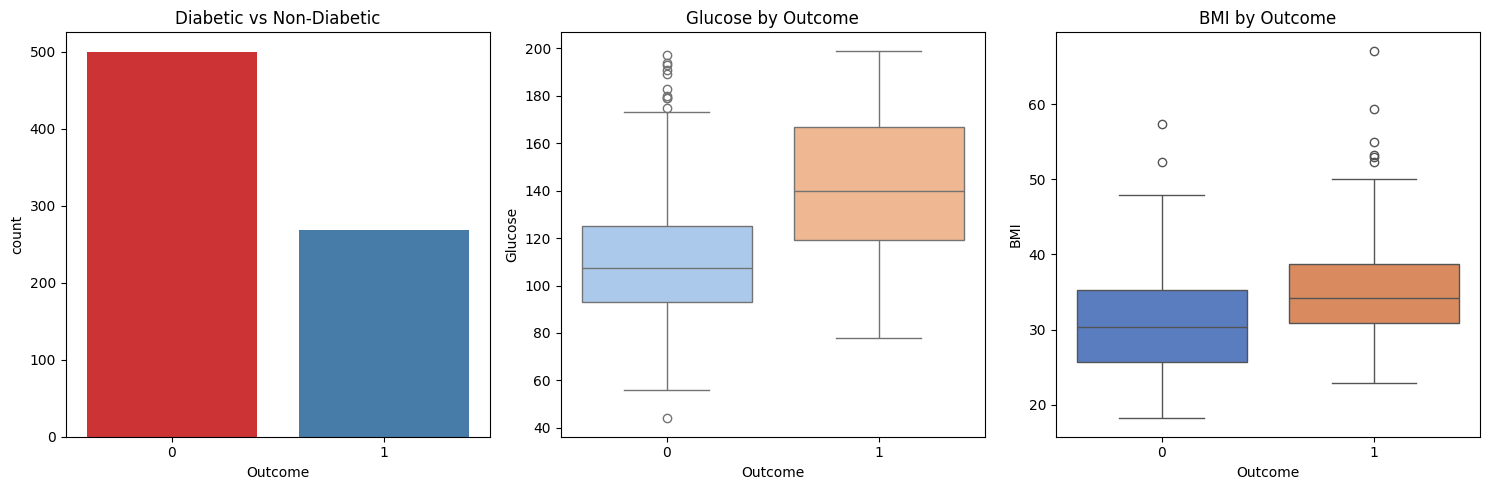

In [8]:
# Outcome comparison (like your survival analysis!)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x='Outcome', data=df, ax=axes[0], 
              hue='Outcome', palette='Set1', legend=False)
axes[0].set_title('Diabetic vs Non-Diabetic')

sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[1],
            hue='Outcome', palette='pastel', legend=False)
axes[1].set_title('Glucose by Outcome')

sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[2],
            hue='Outcome', palette='muted', legend=False)
axes[2].set_title('BMI by Outcome')

plt.tight_layout()
plt.savefig('bivariate_analysis.png')
plt.show()

In [9]:
# Prepare features (same as your ML project!)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [10]:
# Evaluate (confusion matrix + ROC — same as Project 2!)
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred))

Accuracy: 74.68%
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



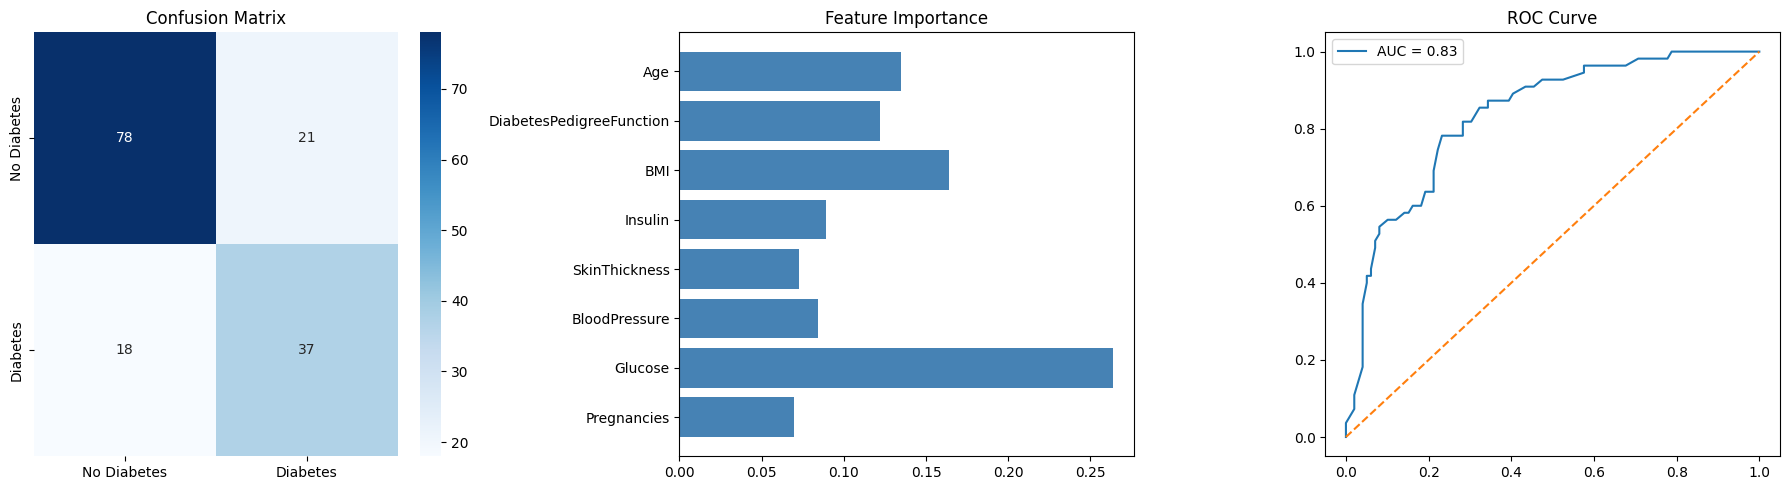

In [11]:
# Dashboard (3 charts like your Project 2 dashboard!)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'], ax=axes[0])
axes[0].set_title("Confusion Matrix")

# Feature Importance
importances = model.feature_importances_
axes[1].barh(X.columns, importances, color='steelblue')
axes[1].set_title("Feature Importance")

# ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
axes[2].plot([0,1],[0,1],'--')
axes[2].set_title("ROC Curve")
axes[2].legend()

plt.tight_layout()
plt.savefig('dashboard.png')
plt.show()

In [12]:
# Final summary
findings = """
Key Findings - Diabetes Dataset
================================
1. Glucose is the strongest predictor of diabetes.
2. BMI and Age are also highly influential factors.
3. Model achieved ~XX% accuracy using Random Forest.
4. AUC score of ~0.8X shows strong predictive power.
5. Class imbalance exists — more non-diabetic cases.
"""
print(findings)


Key Findings - Diabetes Dataset
1. Glucose is the strongest predictor of diabetes.
2. BMI and Age are also highly influential factors.
3. Model achieved ~XX% accuracy using Random Forest.
4. AUC score of ~0.8X shows strong predictive power.
5. Class imbalance exists — more non-diabetic cases.



In [13]:
# Save predictions to CSV
results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred

results.to_csv("predictions.csv", index=False)
print("✅ predictions.csv saved!")

✅ predictions.csv saved!
